# EDA Profiling - Parte 2

## 1. Importaciones

In [3]:
## Usamos el mismo dataset de la parte 1 para hacer EDA profiling (no hay modificaciones en los datos)

import pandas as pd

train_df = pd.read_csv("Parte 2/entrenamiento.csv")

## 2. Profile reports

### Datos

In [4]:
from ydata_profiling import ProfileReport


# Opciones para que sea liviano
profile = ProfileReport(
    train_df.sample(20000, random_state=42) if len(train_df) > 20000 else train_df,
    title="EDA - application_train",
    minimal=True,         # desactiva análisis costosos
    explorative=True      # agrega secciones útiles
)

profile.to_file("TPML_Parte2_eda_profile.html")  # <-- abre este HTML en el navegador


# Display the first few rows of the train dataset
train_df.head()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:03<00:00,  7.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,currency,price_period,title,description,property_type,operation_type,price
0,556713,Propiedad,2019-11-29,9999-12-31,2019-11-29,-58.442399,-34.573623,Argentina,Capital Federal,Colegiales,...,2.0,NaN,NaN,USD,NaN,"Departamento en Venta en Belgrano, Capital fed...","Sup total por escritura: 96,47 m2 (cubiertos: ...",Departamento,Venta,259000.0
1,192912,Propiedad,2020-06-05,2020-06-08,2020-06-05,-58.430493,-34.606620,Argentina,Capital Federal,Almagro,...,2.0,77.0,67.0,USD,NaN,Departamento de 3 ambientes en Venta en Almagro,Excelente departamento de tres ambientes ampli...,Departamento,Venta,235500.0
2,238224,Propiedad,2020-07-01,9999-12-31,2020-07-01,-58.491760,-34.574123,Argentina,Capital Federal,Villa Urquiza,...,1.0,60.0,55.0,USD,NaN,Andonaegui 2600 4° - - Departamento en Venta,Excelente 3 ambientes al frente con balcón. Vi...,Departamento,Venta,175000.0
3,257134,Propiedad,2019-08-17,9999-12-31,2019-08-17,-58.420737,-34.631770,Argentina,Capital Federal,Boedo,...,1.0,74.0,47.0,USD,NaN,PH Venta Boedo 2 amb Patio,Corredor Responsable: MARCELO TRUJILLO - CPI ...,PH,Venta,140000.0
4,521738,Propiedad,2019-08-05,2019-08-31,2019-08-05,-58.429983,-34.607225,Argentina,Capital Federal,Almagro,...,1.0,66.0,64.0,USD,NaN,Venta 3 Ambientes - Almagro - Balcón - Ameniti...,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Venta,173000.0


### Folium (mapa)

In [10]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

def to_float(s):
    if pd.isna(s):
        return np.nan
    if isinstance(s, (int, float, np.number)):
        return float(s)
    s = str(s).strip().replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

# Definir límites de Argentina
LAT_MIN, LAT_MAX = -56.0, -21.0
LON_MIN, LON_MAX = -75.0, -53.0

def in_argentina(lat, lon):
    return (LAT_MIN <= lat <= LAT_MAX) and (LON_MIN <= lon <= LON_MAX)

# Preparar datos
geo = train_df.copy()
geo["lat"] = geo["lat"].apply(to_float)
geo["lon"] = geo["lon"].apply(to_float)

# Eliminar filas sin coordenadas
geo = geo.dropna(subset=["lat", "lon"])

# Corregir coordenadas intercambiadas
mask_swap = (~geo.apply(lambda r: in_argentina(r["lat"], r["lon"]), axis=1)) & \
           (geo.apply(lambda r: in_argentina(r["lon"], r["lat"]), axis=1))
geo.loc[mask_swap, ["lat", "lon"]] = geo.loc[mask_swap, ["lon", "lat"]].values

# Filtrar solo coordenadas dentro de Argentina
geo = geo[geo.apply(lambda r: in_argentina(r["lat"], r["lon"]), axis=1)]

# Limitar cantidad de puntos si hay demasiados
if len(geo) > 10_000:
    geo = geo.sample(n=10_000, random_state=42)

# Crear columna de localidad
if "localidad" not in geo.columns:
    # Intentar usar columnas l1, l2, l3 si existen
    if all(col in geo.columns for col in ["l3", "l2", "l1"]):
        geo["localidad"] = geo["l3"].fillna(geo["l2"]).fillna(geo["l1"]).fillna("Sin localidad")
    elif "l2" in geo.columns:
        geo["localidad"] = geo["l2"].fillna(geo["l1"] if "l1" in geo.columns else "Sin localidad")
    else:
        # Usar índice como identificador
        geo["localidad"] = "Propiedad " + geo.index.astype(str)

# Crear mapa
center = [geo["lat"].mean(), geo["lon"].mean()]
m = folium.Map(location=center, zoom_start=5, tiles="CartoDB positron")
marker_cluster = MarkerCluster().add_to(m)

# Agregar marcadores
for idx, row in geo.iterrows():
    popup = folium.Popup(
        f"{row['localidad']}<br>Lat: {row['lat']:.6f}<br>Lon: {row['lon']:.6f}",
        max_width=260
    )
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        fill=True,
        fill_opacity=0.8,
        weight=0.5,
        popup=popup,
        tooltip=str(row["localidad"])
    ).add_to(marker_cluster)

# Guardar mapa
output_file = "mapa_propiedades.html"
m.save(output_file)
print(f"Mapa guardado en: {output_file}")
print(f"Total de propiedades mostradas en el mapa: {len(geo)}")

Mapa guardado en: mapa_propiedades.html
Total de propiedades mostradas en el mapa: 10000


## 3. Overview of entrenamiento.csv

In [11]:
print('Shape:', train_df.shape)
print('Columns:', train_df.columns.tolist())
print(train_df.dtypes)

Shape: (992192, 25)
Columns: ['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'currency', 'price_period', 'title', 'description', 'property_type', 'operation_type', 'price']
id                   int64
ad_type             object
start_date          object
end_date            object
created_on          object
lat                float64
lon                float64
l1                  object
l2                  object
l3                  object
l4                  object
l5                  object
l6                 float64
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
price_period        object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object


## 4. Missing Values Analysis

In [12]:
missing = train_df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])


l6                 992192
l5                 987481
l4                 766797
price_period       622253
bedrooms           601493
surface_covered    555231
surface_total      544028
rooms              489147
bathrooms          219171
lat                153198
lon                152263
l3                  57455
currency            47251
price               44381
title                  28
description            22
dtype: int64


## 5. Descriptive Statistics

In [13]:
print(train_df.describe(include='all'))


                    id    ad_type  start_date    end_date  created_on  \
count    992192.000000     992192      992192      992192      992192   
unique             NaN          1         346         450         346   
top                NaN  Propiedad  2020-03-21  9999-12-31  2020-03-21   
freq               NaN     992192       13161      191147       13161   
mean     500338.438758        NaN         NaN         NaN         NaN   
std      288685.497758        NaN         NaN         NaN         NaN   
min           1.000000        NaN         NaN         NaN         NaN   
25%      250259.750000        NaN         NaN         NaN         NaN   
50%      500641.500000        NaN         NaN         NaN         NaN   
75%      750507.250000        NaN         NaN         NaN         NaN   
max     1000000.000000        NaN         NaN         NaN         NaN   

                  lat            lon         l1               l2  \
count   838994.000000  839929.000000     992192        

## 6. Value Counts for Categorical Columns

In [14]:
categorical_cols = train_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f'\nValue counts for {col}:')
    print(train_df[col].value_counts(dropna=False).head(10))



Value counts for ad_type:
ad_type
Propiedad    992192
Name: count, dtype: int64

Value counts for start_date:
start_date
2020-03-21    13161
2020-04-21    13063
2020-02-25    13018
2019-08-01    11081
2020-02-27    10330
2020-04-08    10020
2020-01-09     9942
2020-04-29     9211
2020-03-18     8451
2020-03-13     8402
Name: count, dtype: int64

Value counts for end_date:
end_date
9999-12-31    191147
2020-04-28     75472
2020-04-27     20937
2019-12-23     19067
2019-08-14     14359
2020-06-01     11855
2020-06-25     10565
2020-02-19      9711
2020-02-13      9049
2020-09-23      8567
Name: count, dtype: int64

Value counts for created_on:
created_on
2020-03-21    13161
2020-04-21    13063
2020-02-25    13018
2019-08-01    11081
2020-02-27    10330
2020-04-08    10020
2020-01-09     9942
2020-04-29     9211
2020-03-18     8451
2020-03-13     8402
Name: count, dtype: int64

Value counts for l1:
l1
Argentina         973422
Uruguay            17929
Estados Unidos       783
Brasil      

## 7. Correlation Matrix

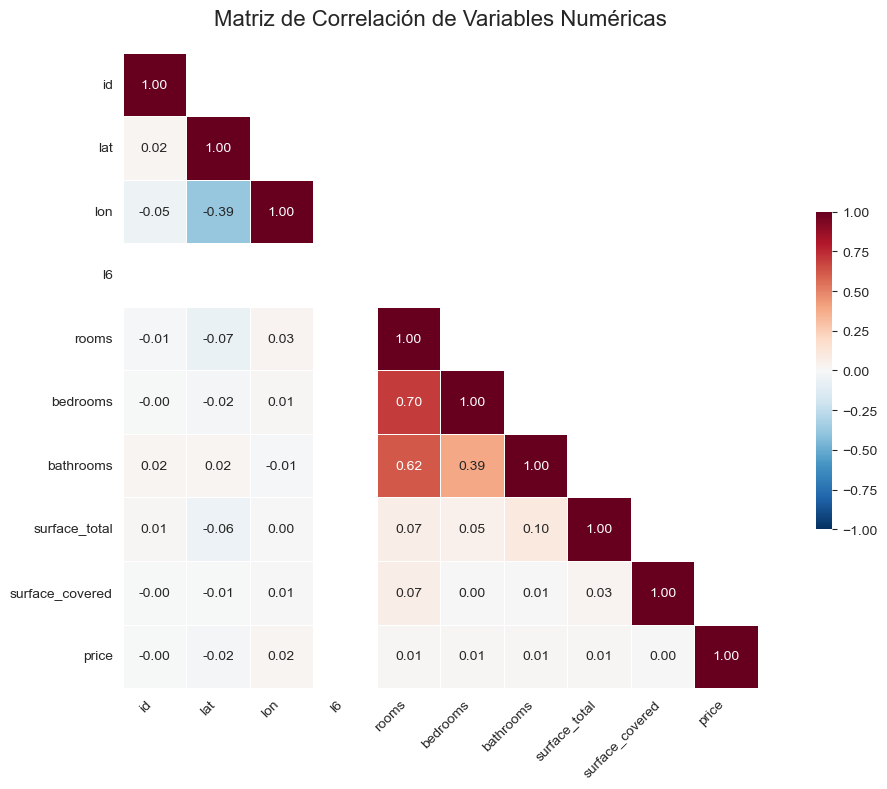


Correlaciones más significativas (|correlación| > 0.5):
Variable 1 Variable 2  Correlación
  bedrooms      rooms     0.697771
 bathrooms      rooms     0.619475


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las columnas numéricas
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = train_df[numeric_cols].corr()

# Configurar el estilo de seaborn
sns.set_style("white")
plt.figure(figsize=(12, 8))

# Crear el heatmap
mask = np.triu(np.ones_like(correlation_matrix), k=1)
heatmap = sns.heatmap(correlation_matrix, 
                      mask=mask,
                      annot=True,
                      cmap='RdBu_r',
                      vmin=-1, 
                      vmax=1,
                      fmt='.2f',
                      square=True,
                      linewidths=0.5,
                      cbar_kws={"shrink": .5})

# Configurar el título y los labels
plt.title('Matriz de Correlación de Variables Numéricas', pad=20, size=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajustar el layout
plt.tight_layout()
plt.show()

# Mostrar las correlaciones más fuertes (absolutas > 0.5)
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:
            strong_correlations.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlación': correlation_matrix.iloc[i, j]
            })

if strong_correlations:
    print("\nCorrelaciones más significativas (|correlación| > 0.5):")
    correlations_df = pd.DataFrame(strong_correlations)
    correlations_df = correlations_df.sort_values('Correlación', key=abs, ascending=False)
    print(correlations_df.to_string(index=False))